# AQUATIME CS1 — LightGBM MALH Retrieval
## Starting from prepared datasets

**Input datasets (already prepared ):**
- `case1_full_dataset_for_ML.csv` — 1384 rows, RT1 + CPOWER, 2020–2025, ancillary + spectral
- `case1_extra_phaeo_inputs.csv` — 808 rows, bloom-only augmentation spectra (MALH > 0.003)

**Pipeline:**
- §3: Combine datasets → cyclical DOY encoding → temporal split
- §4: Scenario 1 — MALH from hyperspectral reflectance + ancillary data
- §5: Scemario 2 — MALH from ancillary + last known MALH (CHIME gap model)
- §6: Gap sensitivity sweep
- §7: Side-by-side comparison



## §0. Configuration

In [1]:
from phytospec import config as cfg
from pathlib import Path

# ── Data paths ────────────────────────────────────────────────────────────────
ML_DIR   = cfg.DATA_RAW / 'DATA_FOR_ML'
FIG_DIR  = cfg.FIGURES_DIR / 'ML_CASE1'
MODEL_DIR = cfg.DATA_PROCESSED / 'MODELS' / 'CS1'

FIG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# ── Input files (Prepared datasets) ─────────────────────────────────
FULL_DATASET_FILE  = ML_DIR / 'case1_full_dataset_for_ML.csv'
EXTRA_PHAEO_FILE   = ML_DIR / 'case1_extra_phaeo_inputs.csv'

# ── Spectral range used in training ───────────────────────────────────────────
WL_MIN, WL_MAX, WL_STEP = 400, 800, 2.5   # nm

# ── Training settings ─────────────────────────────────────────────────────────
TEST_FRACTION   = 0.20    # last 20% chronologically goes to test
N_LGBM_TRIALS   = 50     # Optuna trials (0 = skip, use defaults)

# ── Scenario 2 gap sweep ────────────────────────────────────────────────────────
GAP_DAYS_LIST = [1, 2, 4, 7, 12, 16, 21, 30]
GAP_EXAMPLE   = 12

# ── MALH class thresholds (Lavigne 2022 / R-pipeline) ─────────────────────────
T_ABSENCE  = 0.003   # m⁻¹
T_PRESENCE = 0.010   # m⁻¹
CLASS_NAMES = ['Absence\n(<0.003)', 'Uncertainty\n(0.003–0.010)', 'Presence\n(>0.010)']

# Sanity check
print("FULL_DATASET_FILE exists:", FULL_DATASET_FILE.exists())
print("EXTRA_PHAEO_FILE  exists:", EXTRA_PHAEO_FILE.exists())

FULL_DATASET_FILE exists: True
EXTRA_PHAEO_FILE  exists: True


## §1. Imports

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import lightgbm as lgb
import joblib, json

from sklearn.metrics import (mean_squared_error, r2_score,
                             classification_report, ConfusionMatrixDisplay)
from sklearn.model_selection import TimeSeriesSplit

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    HAS_OPTUNA = True
except ImportError:
    HAS_OPTUNA = False
    print("optuna not installed — pip install optuna to enable hyperparameter tuning.")

print("LightGBM", lgb.__version__)

LightGBM 4.6.0


## §2. Utility Functions

In [3]:
# ── MALH classification ────────────────────────────────────────────────────
def malh_to_class(values: np.ndarray) -> np.ndarray:
    """0 = Absence, 1 = Uncertainty, 2 = Presence."""
    return np.where(values < T_ABSENCE, 0,
           np.where(values < T_PRESENCE, 1, 2))


# ── Temporal split ─────────────────────────────────────────────────────────
def temporal_split(df, test_frac=0.20, sort_col='year_doy'):
    """Chronological split — train on earlier data, test on later."""
    df = df.sort_values(sort_col).reset_index(drop=True)
    idx = int(len(df) * (1 - test_frac))
    return df.iloc[:idx].copy(), df.iloc[idx:].copy()


# ── Cyclical DOY encoding ──────────────────────────────────────────────────
def add_cyclical_doy(df, doy_col='day_of_year'):
    """Replace raw DOY integer with sin/cos to correctly handle Dec→Jan wrap."""
    df = df.copy()
    doy = df[doy_col]
    df['doy_sin'] = np.sin(2 * np.pi * doy / 365)
    df['doy_cos'] = np.cos(2 * np.pi * doy / 365)
    return df.drop(columns=[doy_col])


# ── Evaluation ─────────────────────────────────────────────────────────────
def evaluate(y_true, y_pred, title=''):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    bias = np.mean(y_pred - y_true)
    print(f"{'─'*42}")
    if title: print(f'  {title}')
    print(f'  RMSE : {rmse:.5f} m⁻¹')
    print(f'  R²   : {r2:.4f}')
    print(f'  Bias : {bias:.5f} m⁻¹')
    print(f"{'─'*42}")
    return {'rmse': rmse, 'r2': r2, 'bias': bias}


def scatter_malh(y_true, y_pred, title='', ax=None):
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(6, 6))
    lim = (min(-0.005, y_true.min()*1.1), max(y_true.max(), y_pred.max())*1.1)
    ax.scatter(y_true, y_pred, alpha=0.4, s=20, edgecolors='none')
    ax.plot(lim, lim, 'r--', lw=1.2, label='1:1')
    for t, ls in [(T_ABSENCE, ':'), (T_PRESENCE, '--')]:
        ax.axvline(t, color='steelblue', lw=0.8, ls=ls)
        ax.axhline(t, color='steelblue', lw=0.8, ls=ls)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    ax.text(0.05, 0.92, f'RMSE={rmse:.4f}\nR²={r2:.3f}',
            transform=ax.transAxes, va='top', fontsize=9,
            bbox=dict(boxstyle='round', fc='white', alpha=0.7))
    ax.set_xlabel('True MALH (m⁻¹)'); ax.set_ylabel('Predicted MALH (m⁻¹)')
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_title(title); ax.grid(alpha=0.3); ax.legend(fontsize=8)
    if standalone:
        plt.tight_layout()
        return fig


def save_model(model, features, run_name):
    out = MODEL_DIR / run_name
    out.mkdir(parents=True, exist_ok=True)
    model.booster_.save_model(str(out / 'lgbm_model.txt'))
    with open(out / 'features.json', 'w') as f:
        json.dump(list(features), f, indent=2)
    print(f'Model saved → {out}')

## §3. Load & Combine Datasets

**What each file contains:**

| File | Content |
|---|---|
| `case1_full_dataset_for_ML.csv` | Main dataset: RT1 + CPOWER, 2020–2025. Reflectance, D2, ancillary (CHL/SPM/SST/NO3/PO4), MALH. Balanced classes. |
| `case1_extra_phaeo_inputs.csv` | Augmentation: extra PANTHYR bloom spectra (MALH > 0.003 only). No ANC data (NaN). Used in step 3.5 of the pipeline. |

Both have identical columns — we concatenate them directly.

In [4]:
# ── Load ──────────────────────────────────────────────────────────────────
full  = pd.read_csv(FULL_DATASET_FILE)
extra = pd.read_csv(EXTRA_PHAEO_FILE)

print(f"Full dataset : {full.shape[0]} rows  |  years: {sorted(full['year'].unique())}")
print(f"Extra phaeo  : {extra.shape[0]} rows  |  years: {sorted(extra['year'].unique())}")
print(f"Extra SPM all NaN: {extra['SPM'].isna().all()}  "
      f"(spectral only, no ancillary — expected)")

Full dataset : 1384 rows  |  years: [np.int64(2020), np.int64(2022), np.int64(2024), np.int64(2025)]
Extra phaeo  : 808 rows  |  years: [np.int64(2020), np.int64(2022), np.int64(2024), np.int64(2025)]
Extra SPM all NaN: True  (spectral only, no ancillary — expected)


In [5]:
# ── §3.5 Combine (as per pipeline step 3.5) ──────────────────────────────
# Mark source so we can inspect them separately if needed
full['source']  = 'full'
extra['source'] = 'extra'

df_raw = pd.concat([full, extra], ignore_index=True)

# ── MALH class column ─────────────────────────────────────────────────────
df_raw['MALH_class'] = malh_to_class(df_raw['MALH'].values)

print(f"Combined: {len(df_raw)} rows")
print(f"\nClass distribution:")
for i, name in enumerate(CLASS_NAMES):
    n = (df_raw['MALH_class']==i).sum()
    print(f"  {name.split(chr(10))[0]}: {n} ({n/len(df_raw):.1%})")

# Station × year breakdown
print(f"\nRows per station × year:")
print(df_raw.groupby(['station','year']).size().to_string())

Combined: 2192 rows

Class distribution:
  Absence: 538 (24.5%)
  Uncertainty: 868 (39.6%)
  Presence: 786 (35.9%)

Rows per station × year:
station  year
CPOWER   2024     85
         2025     40
RT1      2020    518
         2022    244
         2024    314
         2025    991


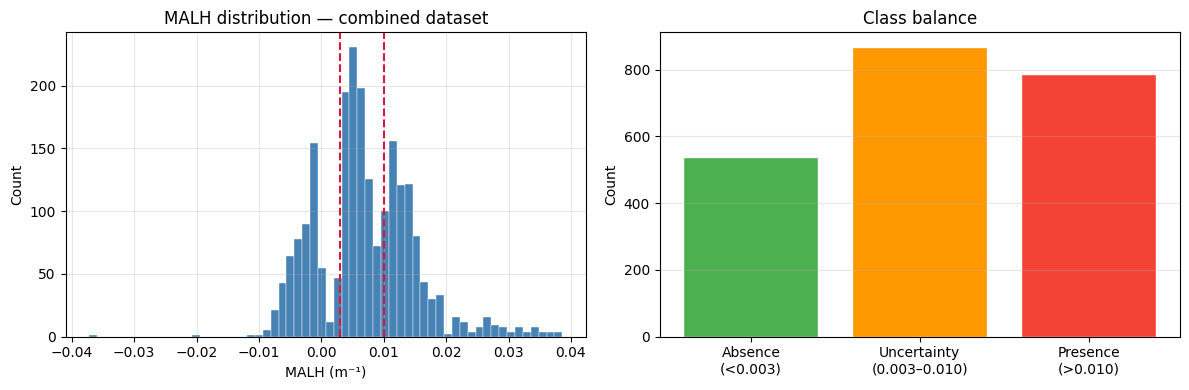

Good class balance — model can learn all three regimes.


In [6]:
# ── Visualise class balance ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_raw['MALH'], bins=60, color='steelblue', edgecolor='white', lw=0.3)
for t in [T_ABSENCE, T_PRESENCE]:
    axes[0].axvline(t, color='crimson', lw=1.5, ls='--')
axes[0].set_xlabel('MALH (m⁻¹)'); axes[0].set_ylabel('Count')
axes[0].set_title('MALH distribution — combined dataset')
axes[0].grid(alpha=0.3)

counts = pd.Series(df_raw['MALH_class']).value_counts().sort_index()
axes[1].bar([CLASS_NAMES[i] for i in counts.index], counts.values,
            color=['#4caf50','#ff9800','#f44336'], edgecolor='white')
axes[1].set_ylabel('Count'); axes[1].set_title('Class balance')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(FIG_DIR / 'malh_distribution_combined.png', dpi=150)
plt.show()
print("Good class balance — model can learn all three regimes.")

### §3.2 Feature Engineering

In [7]:
# ── Build spectral column lists ──────────────────────────────────────────
wavelengths  = np.arange(WL_MIN, WL_MAX, WL_STEP)
rhow_cols    = [f'rhow_{wl}'   for wl in wavelengths if f'rhow_{wl}'   in df_raw.columns]
d2rho_cols   = [f'D2rhow_{wl}' for wl in wavelengths if f'D2rhow_{wl}' in df_raw.columns]
anc_cols     = [c for c in ['chl','SPM','temp','NO3','PO4'] if c in df_raw.columns]

print(f"Spectral bands (rhow):   {len(rhow_cols)}")
print(f"Spectral bands (D2rhow): {len(d2rho_cols)}")
print(f"Ancillary columns:       {anc_cols}")

# ── Cyclical DOY encoding ─────────────────────────────────────────────────
df_feat = add_cyclical_doy(df_raw, doy_col='day_of_year')

# ── Sort key for temporal split ──────────────────────────────────────────
df_feat['year_doy'] = df_feat['year'] * 1000 + (df_feat['doy_sin'] * 0 + 
    df_raw['day_of_year'])   # reconstruct for sorting

# Drop metadata columns not used as features
META = ['station', 'unit_key', 'MALH_cat', 'MALH_class', 'source', 'year_doy']
META = [c for c in META if c in df_feat.columns]

# Drop rows with NaN in key columns (extra dataset has NaN in SPM/temp)
# Strategy: keep NaN rows but they will naturally have lower influence
# because LGBM handles NaN natively — NO imputation needed
df_feat = df_feat.dropna(subset=['MALH'] + rhow_cols[:5])  # only drop if spectral missing

print(f"\nDataset after feature engineering: {df_feat.shape[0]} rows × {df_feat.shape[1]} cols")
print(f"NaN in ancillary (from extra dataset):")
for c in anc_cols:
    print(f"  {c}: {df_feat[c].isna().sum()} NaN "
          f"({'expected from extra dataset' if df_feat[c].isna().sum() > 0 else 'OK'})")

Spectral bands (rhow):   160
Spectral bands (D2rhow): 160
Ancillary columns:       ['chl', 'SPM', 'temp', 'NO3', 'PO4']

Dataset after feature engineering: 2192 rows × 335 cols
NaN in ancillary (from extra dataset):
  chl: 0 NaN (OK)
  SPM: 808 NaN (expected from extra dataset)
  temp: 808 NaN (expected from extra dataset)
  NO3: 808 NaN (expected from extra dataset)
  PO4: 808 NaN (expected from extra dataset)


### §3.3 Temporal Train/Test Split

> Chronological split — no bloom event leaks between train and test.

In [8]:
FEATURE_COLS = [c for c in df_feat.columns
                if c not in META + ['MALH', 'year']]

# Sort by year then doy for temporal split
sort_df = df_feat.copy()
sort_df['_sort'] = sort_df['year'] * 1000 + df_raw.loc[sort_df.index, 'day_of_year']
sort_df = sort_df.sort_values('_sort').reset_index(drop=True)

split_idx = int(len(sort_df) * (1 - TEST_FRACTION))
train_df  = sort_df.iloc[:split_idx].copy()
test_df   = sort_df.iloc[split_idx:].copy()

X_train = train_df[FEATURE_COLS].values
y_train = train_df['MALH'].values
X_test  = test_df[FEATURE_COLS].values
y_test  = test_df['MALH'].values

print(f"Train: {len(train_df)} rows  |  years: {sorted(train_df['year'].unique())}")
print(f"Test : {len(test_df)}  rows  |  years: {sorted(test_df['year'].unique())}")
print(f"Feature count: {len(FEATURE_COLS)}")

for split_name, y in [('Train', y_train), ('Test', y_test)]:
    cls, cnt = np.unique(malh_to_class(y), return_counts=True)
    fracs = cnt / cnt.sum()
    print(f"{split_name} classes: " +
          "  ".join(f"{CLASS_NAMES[c].split(chr(10))[0]}={f:.1%}" 
                    for c, f in zip(cls, fracs)))

Train: 1753 rows  |  years: [np.int64(2020), np.int64(2022), np.int64(2024), np.int64(2025)]
Test : 439  rows  |  years: [np.int64(2025)]
Feature count: 327
Train classes: Absence=28.4%  Uncertainty=35.5%  Presence=36.2%
Test classes: Absence=9.3%  Uncertainty=56.0%  Presence=34.6%


## §4. Hyperparameter Tuning (Optuna) — set N_LGBM_TRIALS=0 to skip

In [9]:
best_params = {
    'n_estimators':      500,
    'learning_rate':     0.05,
    'num_leaves':        63,
    'min_child_samples': 20,
    'subsample':         0.8,
    'colsample_bytree':  0.6,
    'random_state':      42,
    'n_jobs':            -1,
    'verbose':           -1,
}

if HAS_OPTUNA and N_LGBM_TRIALS > 0:
    tscv = TimeSeriesSplit(n_splits=5)

    def objective(trial):
        params = {
            'n_estimators':      trial.suggest_int('n_estimators', 200, 1500),
            'learning_rate':     trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
            'num_leaves':        trial.suggest_int('num_leaves', 20, 200),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 60),
            'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.3, 1.0),
            'reg_alpha':         trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
            'reg_lambda':        trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
            'random_state': 42, 'n_jobs': -1, 'verbose': -1,
        }
        scores = []
        for tr, vl in tscv.split(X_train):
            m = lgb.LGBMRegressor(**params)
            m.fit(X_train[tr], y_train[tr])
            scores.append(mean_squared_error(y_train[vl], m.predict(X_train[vl])))
        return np.mean(scores)

    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=N_LGBM_TRIALS, show_progress_bar=True)
    best_params.update(study.best_params)
    print("Best params found:", study.best_params)
    print(f"Best CV MSE: {study.best_value:.6f}")
else:
    print("Using default parameters.")

print("\nParameters:", best_params)

Best trial: 25. Best value: 8.2842e-06: 100%|██████████| 50/50 [12:21<00:00, 14.83s/it] 

Best params found: {'n_estimators': 652, 'learning_rate': 0.011762864371385295, 'num_leaves': 85, 'min_child_samples': 29, 'subsample': 0.9346902358280854, 'colsample_bytree': 0.4140981778039708, 'reg_alpha': 0.0003375552690844069, 'reg_lambda': 0.0061856557634038046}
Best CV MSE: 0.000008

Parameters: {'n_estimators': 652, 'learning_rate': 0.011762864371385295, 'num_leaves': 85, 'min_child_samples': 29, 'subsample': 0.9346902358280854, 'colsample_bytree': 0.4140981778039708, 'random_state': 42, 'n_jobs': -1, 'verbose': -1, 'reg_alpha': 0.0003375552690844069, 'reg_lambda': 0.0061856557634038046}


## §5. Scenario 1 — MALH from Hyperspectral Reflectance + Ancillary Data

> Note: LightGBM handles NaN natively — no imputation needed for the extra phaeo rows.

In [10]:
model_hyp = lgb.LGBMRegressor(**best_params)
model_hyp.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False),
               lgb.log_evaluation(period=-1)],
)
y_pred_hyp = model_hyp.predict(X_test)
metrics_hyp = evaluate(y_test, y_pred_hyp, title='Scenario 1 — Hyperspectral + ANC')

──────────────────────────────────────────
  Scenario 1 — Hyperspectral + ANC
  RMSE : 0.00083 m⁻¹
  R²   : 0.9842
  Bias : -0.00016 m⁻¹
──────────────────────────────────────────


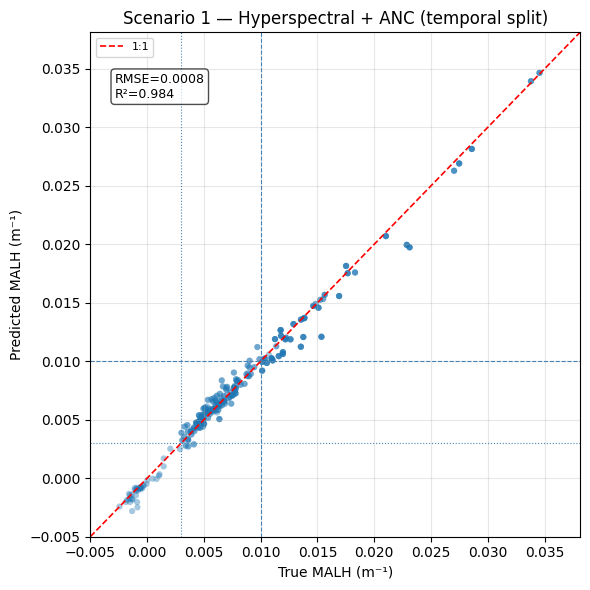

In [11]:
fig = scatter_malh(y_test, y_pred_hyp,
                   title='Scenario 1 — Hyperspectral + ANC (temporal split)')
fig.savefig(FIG_DIR / 'lgbm_scatter_hyperspectral.png', dpi=150)
plt.show()

                           precision    recall  f1-score   support

         Absence
(<0.003)       0.87      1.00      0.93        41
Uncertainty
(0.003–0.010)       0.95      0.95      0.95       246
        Presence
(>0.010)       0.96      0.92      0.94       152

                 accuracy                           0.95       439
                macro avg       0.93      0.96      0.94       439
             weighted avg       0.95      0.95      0.95       439



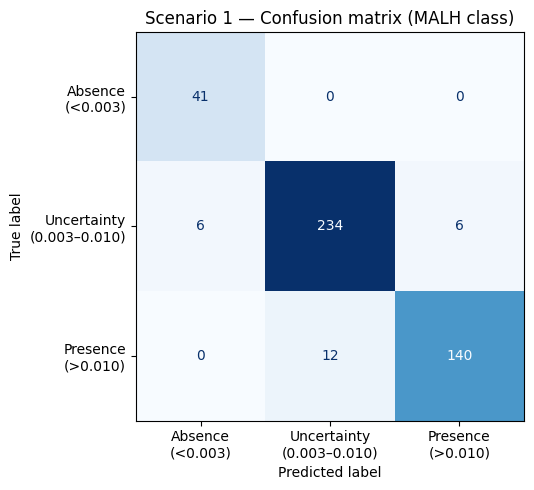

In [12]:
# ── Classification metrics at MALH thresholds ───────────────────────────
y_test_cls = malh_to_class(y_test)
y_pred_cls = malh_to_class(y_pred_hyp)

print(classification_report(y_test_cls, y_pred_cls,
      labels=[0,1,2], target_names=CLASS_NAMES, zero_division=0))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_cls, y_pred_cls,
    labels=[0,1,2], display_labels=CLASS_NAMES,
    cmap='Blues', ax=ax, colorbar=False,
)
ax.set_title('Scenario 1 — Confusion matrix (MALH class)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'lgbm_confusion_hyperspectral.png', dpi=150)
plt.show()

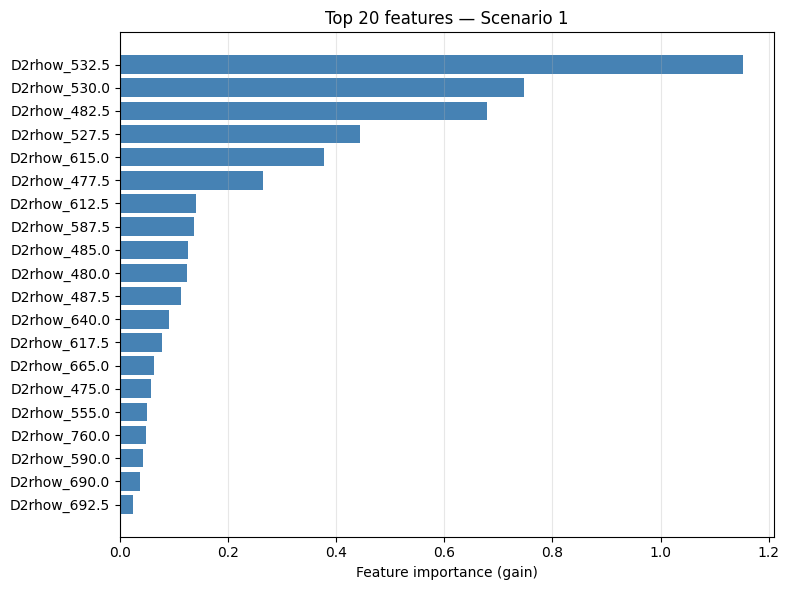

Top 10 features:
     feature  importance
D2rhow_532.5    1.151607
D2rhow_530.0    0.747230
D2rhow_482.5    0.679250
D2rhow_527.5    0.444552
D2rhow_615.0    0.377832
D2rhow_477.5    0.264229
D2rhow_612.5    0.141478
D2rhow_587.5    0.136660
D2rhow_485.0    0.126725
D2rhow_480.0    0.124739


In [13]:
# ── Feature importance (top 20) ─────────────────────────────────────────
importance = model_hyp.booster_.feature_importance(importance_type='gain')
fi_df = (pd.DataFrame({'feature': FEATURE_COLS, 'importance': importance})
           .sort_values('importance', ascending=False).head(20))

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(fi_df['feature'][::-1], fi_df['importance'][::-1], color='steelblue')
ax.set_xlabel('Feature importance (gain)')
ax.set_title('Top 20 features — Scenario 1')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(FIG_DIR / 'lgbm_feature_importance_hyperspectral.png', dpi=150)
plt.show()

print("Top 10 features:")
print(fi_df[['feature','importance']].head(10).to_string(index=False))

In [16]:
save_model(model_hyp, FEATURE_COLS, run_name='case1_hyperspectral')

Model saved → C:\Users\gvillegas\OneDrive - Institute of Natural Sciences\Projects\REMSEM\aquatime\AQUAPHYTO\data\processed\MODELS\CS1\case1_hyperspectral


## §6. Scenario 2 — MALH from Ancillary + Last Known MALH (CHIME Gap Model)

When CHIME has not passed over the site for `x` days, no new reflectance is available.
This model uses only ancillary data + the MALH value measured `x` days ago.

In [17]:
def build_gap_dataset(df_full, gap_days, feature_cols):
    """
    Replace spectral columns with MALH value from `gap_days` ago.
    Vectorized shift — no slow row iteration.
    """
    # Use only the full dataset (not extra phaeo which has no temporal sequence)
    df = df_full[df_full['source']=='full'].copy() if 'source' in df_full.columns else df_full.copy()
    df = df.sort_values(['station','year','_sort'] 
                        if '_sort' in df.columns else ['station','year']).reset_index(drop=True)

    df['last_MALH'] = df.groupby(['station','year'])['MALH'].shift(gap_days)

    # Drop spectral columns, keep ancillary + temporal + last_MALH
    spec = [c for c in feature_cols if c.startswith('rhow_') or c.startswith('D2rhow_')]
    gap_feats = [c for c in feature_cols if c not in spec] + ['last_MALH']

    return df[['year','MALH','station'] + gap_feats].dropna()

──────────────────────────────────────────
  Scenario 2 — gap = 12 days
  RMSE : 0.00528 m⁻¹
  R²   : 0.4611
  Bias : -0.00038 m⁻¹
──────────────────────────────────────────


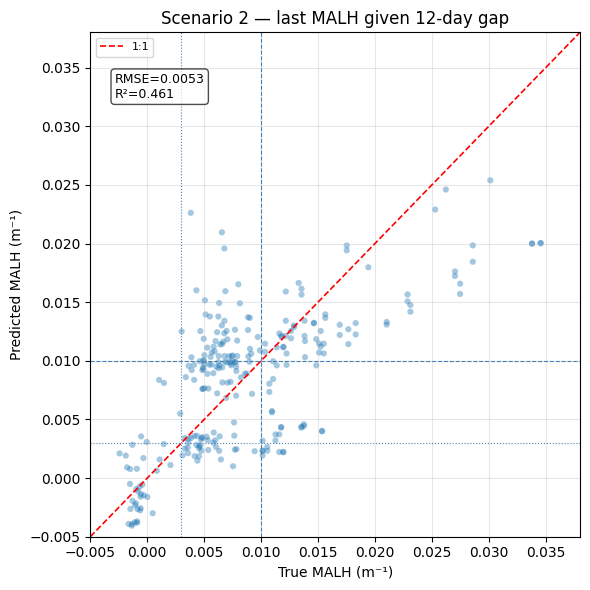

Model saved → C:\Users\gvillegas\OneDrive - Institute of Natural Sciences\Projects\REMSEM\aquatime\AQUAPHYTO\data\processed\MODELS\CS1\scenario2_gap_12days


In [18]:
# ── Single example: gap = 12 days ───────────────────────────────────────
sort_df_full = sort_df.copy()
df_gap_ex = build_gap_dataset(sort_df_full, GAP_EXAMPLE, FEATURE_COLS)

split_g = int(len(df_gap_ex) * (1 - TEST_FRACTION))
GAP_FEATS = [c for c in df_gap_ex.columns if c not in ['year','MALH','station']]
X_tr_g = df_gap_ex.iloc[:split_g][GAP_FEATS].values
y_tr_g = df_gap_ex.iloc[:split_g]['MALH'].values
X_te_g = df_gap_ex.iloc[split_g:][GAP_FEATS].values
y_te_g = df_gap_ex.iloc[split_g:]['MALH'].values

model_gap = lgb.LGBMRegressor(**best_params)
model_gap.fit(X_tr_g, y_tr_g,
              eval_set=[(X_te_g, y_te_g)],
              callbacks=[lgb.early_stopping(50, verbose=False),
                         lgb.log_evaluation(period=-1)])
y_pred_gap = model_gap.predict(X_te_g)
metrics_gap = evaluate(y_te_g, y_pred_gap,
                       title=f'Scenario 2 — gap = {GAP_EXAMPLE} days')

fig = scatter_malh(y_te_g, y_pred_gap,
                   title=f'Scenario 2 — last MALH given {GAP_EXAMPLE}-day gap')
fig.savefig(FIG_DIR / f'lgbm_scatter_gap_{GAP_EXAMPLE}days.png', dpi=150)
plt.show()
save_model(model_gap, GAP_FEATS, run_name=f'scenario2_gap_{GAP_EXAMPLE}days')

## §7. Gap Sensitivity Sweep

In [19]:
print("Running gap sweep ...")
sweep = {}

for gap in GAP_DAYS_LIST:
    df_g = build_gap_dataset(sort_df_full, gap, FEATURE_COLS)
    if len(df_g) < 40:
        print(f"  gap={gap:2d}d — too few samples, skipping")
        continue
    sp = int(len(df_g) * (1 - TEST_FRACTION))
    gf = [c for c in df_g.columns if c not in ['year','MALH','station']]
    m  = lgb.LGBMRegressor(**{**best_params, 'n_estimators': 300})
    m.fit(df_g.iloc[:sp][gf].values, df_g.iloc[:sp]['MALH'].values,
          callbacks=[lgb.log_evaluation(period=-1)])
    pred = m.predict(df_g.iloc[sp:][gf].values)
    true = df_g.iloc[sp:]['MALH'].values
    rmse = np.sqrt(mean_squared_error(true, pred))
    r2   = r2_score(true, pred)
    acc  = np.mean(malh_to_class(pred) == malh_to_class(true))
    sweep[gap] = {'rmse': rmse, 'r2': r2, 'class_acc': acc}
    print(f"  gap={gap:2d}d  RMSE={rmse:.4f}  R²={r2:.3f}  class_acc={acc:.2%}")

print("Done.")

Running gap sweep ...
  gap= 1d  RMSE=0.0048  R²=0.657  class_acc=72.10%
  gap= 2d  RMSE=0.0053  R²=0.571  class_acc=66.91%
  gap= 4d  RMSE=0.0059  R²=0.482  class_acc=66.18%
  gap= 7d  RMSE=0.0058  R²=0.477  class_acc=67.66%
  gap=12d  RMSE=0.0054  R²=0.440  class_acc=56.65%
  gap=16d  RMSE=0.0056  R²=0.354  class_acc=57.36%
  gap=21d  RMSE=0.0059  R²=0.283  class_acc=57.94%
  gap=30d  RMSE=0.0054  R²=0.327  class_acc=60.58%
Done.


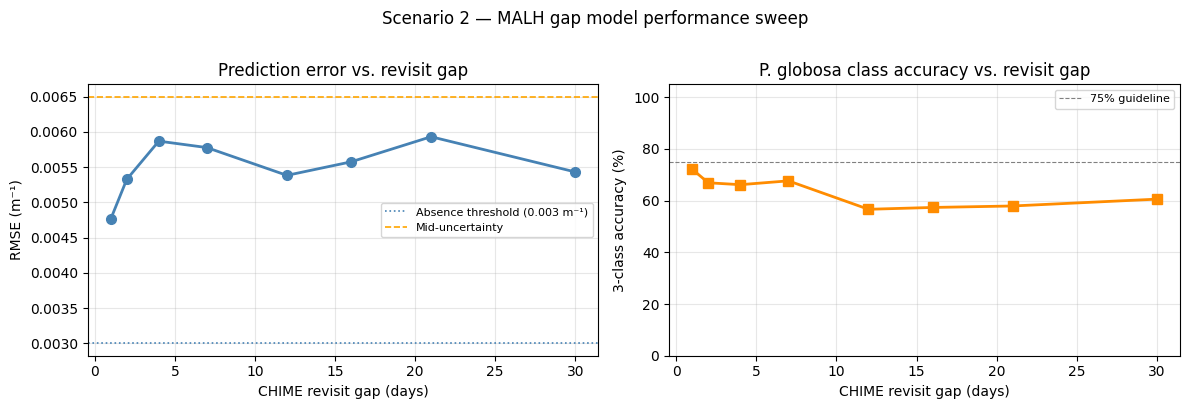

            RMSE (m⁻¹)     R²  3-class acc
Gap (days)                                
1               0.0048 0.6574       0.7210
2               0.0053 0.5712       0.6691
4               0.0059 0.4817       0.6618
7               0.0058 0.4766       0.6766
12              0.0054 0.4402       0.5665
16              0.0056 0.3541       0.5736
21              0.0059 0.2831       0.5794
30              0.0054 0.3266       0.6058


In [20]:
gaps  = list(sweep.keys())
rmses = [sweep[g]['rmse']      for g in gaps]
accs  = [sweep[g]['class_acc'] for g in gaps]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(gaps, rmses, 'o-', color='steelblue', lw=2, ms=7)
ax.axhline(T_ABSENCE,  color='steelblue', ls=':', lw=1.2, label=f'Absence threshold ({T_ABSENCE} m⁻¹)')
ax.axhline((T_ABSENCE + T_PRESENCE)/2, color='orange', ls='--', lw=1.2, label='Mid-uncertainty')
ax.set_xlabel('CHIME revisit gap (days)'); ax.set_ylabel('RMSE (m⁻¹)')
ax.set_title('Prediction error vs. revisit gap')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))

ax = axes[1]
ax.plot(gaps, [a*100 for a in accs], 's-', color='darkorange', lw=2, ms=7)
ax.axhline(75, color='grey', ls='--', lw=0.8, label='75% guideline')
ax.set_xlabel('CHIME revisit gap (days)'); ax.set_ylabel('3-class accuracy (%)')
ax.set_title('P. globosa class accuracy vs. revisit gap')
ax.set_ylim(0, 105); ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))

plt.suptitle('Scenario 2 — MALH gap model performance sweep', y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'lgbm_gap_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

# ── FIX: build summary table from dict of dicts ──────────────────────────────
sweep_df = pd.DataFrame(sweep).T   # rows=gaps, cols=rmse/r2/class_acc
sweep_df.index.name = 'Gap (days)'
sweep_df.columns = ['RMSE (m⁻¹)', 'R²', '3-class acc']
print(sweep_df.to_string(float_format='{:.4f}'.format))

## §7b. Deep Dive — Why Is RMSE Non-Monotonic with Revisit Gap?

The gap sweep (§7) shows that RMSE does **not** decrease monotonically with increasing gap.
For example, a 4-day gap may produce *higher* error than a 12-day gap.
This section demonstrates the three compounding mechanisms:

1. **Different test-set compositions** — `dropna()` after the lag-shift removes different rows at
   each gap, so the per-gap test sets are not the same observations.
2. **Feature compensation** — as `last_MALH` grows stale, the model shifts reliance onto
   ancillary features (CHL, DOY); when CHL happens to be informative for the surviving test rows,
   RMSE can drop even at longer gaps.
3. **MALH serial autocorrelation** — the bloom cycle has a temporal structure; if MALH at lag 12
   still correlates strongly with the current value (e.g., persistent bloom), the stale feature
   is still useful, contradicting the simple intuition that longer gap = worse signal.


In [21]:
# ── §7b.1  Enriched gap sweep — per-class RMSE + feature importance ──────────
# Re-runs the sweep capturing richer diagnostics per gap.
# Runtime: ~1 min (same as §7 but with extra bookkeeping).

print("Running enriched gap sweep for §7b diagnostics ...")
sweep_rich = {}   # gap → rich metrics dict
ANC_TRACK  = ['chl', 'SPM', 'temp', 'NO3', 'PO4', 'doy_sin', 'doy_cos']

for gap in GAP_DAYS_LIST:
    df_g = build_gap_dataset(sort_df_full, gap, FEATURE_COLS)
    if len(df_g) < 40:
        print(f"  gap={gap:2d}d — too few samples, skipping")
        continue

    sp = int(len(df_g) * (1 - TEST_FRACTION))
    gf = [c for c in df_g.columns if c not in ['year', 'MALH', 'station']]

    X_tr = df_g.iloc[:sp][gf].values
    y_tr = df_g.iloc[:sp]['MALH'].values
    X_te = df_g.iloc[sp:][gf].values
    y_te = df_g.iloc[sp:]['MALH'].values

    m = lgb.LGBMRegressor(**{**best_params, 'n_estimators': 300})
    m.fit(X_tr, y_tr, callbacks=[lgb.log_evaluation(period=-1)])
    pred = m.predict(X_te)

    true_cls = malh_to_class(y_te)
    pred_cls = malh_to_class(pred)

    # Per-class RMSE & accuracy
    per_class = {}
    for cls, label in enumerate(['Absence', 'Uncertainty', 'Presence']):
        mask = true_cls == cls
        if mask.sum() == 0:
            per_class[label] = {'n': 0, 'rmse': np.nan, 'acc': np.nan}
            continue
        rmse_c = np.sqrt(mean_squared_error(y_te[mask], pred[mask]))
        acc_c  = np.mean(pred_cls[mask] == cls)
        per_class[label] = {'n': int(mask.sum()), 'rmse': rmse_c, 'acc': acc_c}

    # Test-set class fractions (composition)
    cls_frac = {l: per_class[l]['n'] / len(y_te) for l in per_class}

    # Feature importance — rank of last_MALH and top ancillary
    imp = m.booster_.feature_importance(importance_type='gain')
    fi  = pd.Series(imp, index=gf).sort_values(ascending=False)
    fi_pct = fi / fi.sum() * 100

    lm_rank = int((fi.rank(ascending=False)['last_MALH'])
                  if 'last_MALH' in fi.index else np.nan)
    lm_imp  = float(fi_pct.get('last_MALH', 0.0))
    anc_imp = {c: float(fi_pct.get(c, 0.0)) for c in ANC_TRACK}

    sweep_rich[gap] = {
        'n_test'       : len(y_te),
        'rmse'         : float(np.sqrt(mean_squared_error(y_te, pred))),
        'r2'           : float(r2_score(y_te, pred)),
        'class_acc'    : float(np.mean(pred_cls == true_cls)),
        'per_class'    : per_class,
        'cls_frac'     : cls_frac,
        'last_MALH_imp': lm_imp,
        'last_MALH_rank': lm_rank,
        'anc_imp'      : anc_imp,
    }

    print(f"  gap={gap:2d}d | RMSE={sweep_rich[gap]['rmse']:.4f} | "
          f"n_test={len(y_te)} | "
          f"Absence={cls_frac['Absence']:.0%} Uncert={cls_frac['Uncertainty']:.0%} "
          f"Presence={cls_frac['Presence']:.0%} | "
          f"last_MALH imp={lm_imp:.1f}% (rank #{lm_rank})")

print("Done.")


Running enriched gap sweep for §7b diagnostics ...
  gap= 1d | RMSE=0.0048 | n_test=276 | Absence=15% Uncert=47% Presence=38% | last_MALH imp=51.6% (rank #1)
  gap= 2d | RMSE=0.0053 | n_test=275 | Absence=15% Uncert=48% Presence=37% | last_MALH imp=47.4% (rank #1)
  gap= 4d | RMSE=0.0059 | n_test=272 | Absence=15% Uncert=48% Presence=37% | last_MALH imp=43.9% (rank #1)
  gap= 7d | RMSE=0.0058 | n_test=269 | Absence=15% Uncert=49% Presence=36% | last_MALH imp=37.0% (rank #1)
  gap=12d | RMSE=0.0054 | n_test=263 | Absence=16% Uncert=50% Presence=35% | last_MALH imp=26.4% (rank #2)
  gap=16d | RMSE=0.0056 | n_test=258 | Absence=16% Uncert=51% Presence=33% | last_MALH imp=13.0% (rank #4)
  gap=21d | RMSE=0.0059 | n_test=252 | Absence=16% Uncert=50% Presence=34% | last_MALH imp=12.1% (rank #4)
  gap=30d | RMSE=0.0054 | n_test=241 | Absence=17% Uncert=50% Presence=33% | last_MALH imp=7.9% (rank #5)
Done.


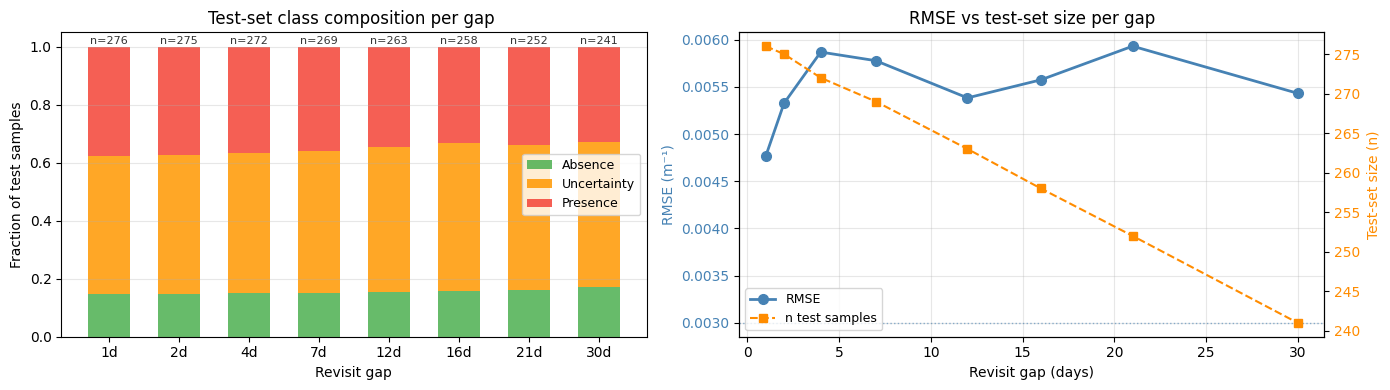

Gap | n_test | Absence% | Uncert% | Presence% | RMSE
------------------------------------------------------------
  1d |   276 | 15%      | 47%     | 38%       | 0.0048
  2d |   275 | 15%      | 48%     | 37%       | 0.0053
  4d |   272 | 15%      | 48%     | 37%       | 0.0059
  7d |   269 | 15%      | 49%     | 36%       | 0.0058
 12d |   263 | 16%      | 50%     | 35%       | 0.0054
 16d |   258 | 16%      | 51%     | 33%       | 0.0056
 21d |   252 | 16%      | 50%     | 34%       | 0.0059
 30d |   241 | 17%      | 50%     | 33%       | 0.0054


In [22]:
# ── §7b.2  Test-set composition per gap ─────────────────────────────────────
# Shows that different gaps produce different test sets.
# If the Presence class fraction rises at gap=4 vs gap=12, that alone
# explains higher RMSE because Presence rows are harder to predict.

gaps_r = list(sweep_rich.keys())

n_tests  = [sweep_rich[g]['n_test']               for g in gaps_r]
frac_abs = [sweep_rich[g]['cls_frac']['Absence']   for g in gaps_r]
frac_unc = [sweep_rich[g]['cls_frac']['Uncertainty'] for g in gaps_r]
frac_pre = [sweep_rich[g]['cls_frac']['Presence']  for g in gaps_r]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── Stacked bar — class composition ───────────────────────────────────────
ax = axes[0]
x = np.arange(len(gaps_r))
w = 0.6
bars_a = ax.bar(x, frac_abs, w, label='Absence',     color='#4caf50', alpha=0.85)
bars_u = ax.bar(x, frac_unc, w, bottom=frac_abs,     label='Uncertainty', color='#ff9800', alpha=0.85)
bars_p = ax.bar(x, frac_pre, w,
                bottom=[a+u for a,u in zip(frac_abs, frac_unc)],
                label='Presence', color='#f44336', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels([f'{g}d' for g in gaps_r])
ax.set_xlabel('Revisit gap'); ax.set_ylabel('Fraction of test samples')
ax.set_title('Test-set class composition per gap '  ) ## '(composition changes because lag-shift + dropna removes different rows)'
ax.legend(fontsize=9); ax.grid(alpha=0.3, axis='y')
# Annotate n_test
for i, n in enumerate(n_tests):
    ax.text(i, 1.01, f'n={n}', ha='center', fontsize=8, color='#333')

# ── n_test vs RMSE dual-axis ───────────────────────────────────────────────
ax2 = axes[1]
rmses_r = [sweep_rich[g]['rmse'] for g in gaps_r]
color_rmse = 'steelblue'
color_n    = 'darkorange'
l1, = ax2.plot(gaps_r, rmses_r, 'o-', color=color_rmse, lw=2, ms=7, label='RMSE')
ax2.axhline(T_ABSENCE,  color='steelblue', ls=':', lw=1, alpha=0.6)
ax2.set_xlabel('Revisit gap (days)'); ax2.set_ylabel('RMSE (m⁻¹)', color=color_rmse)
ax2.tick_params(axis='y', labelcolor=color_rmse)

ax3 = ax2.twinx()
l2, = ax3.plot(gaps_r, n_tests, 's--', color=color_n, lw=1.5, ms=6, label='n test samples')
ax3.set_ylabel('Test-set size (n)', color=color_n)
ax3.tick_params(axis='y', labelcolor=color_n)
ax2.set_title('RMSE vs test-set size per gap'  ) ## '(larger test set ≠ better RMSE — composition matters more than n)'
ax2.legend(handles=[l1, l2], fontsize=9, loc='lower left')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'diag_gap_composition.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print("Gap | n_test | Absence% | Uncert% | Presence% | RMSE")
print("-"*60)
for g in gaps_r:
    r = sweep_rich[g]
    print(f" {g:2d}d |  {r['n_test']:4d} | "
          f"{r['cls_frac']['Absence']:.0%}      | "
          f"{r['cls_frac']['Uncertainty']:.0%}     | "
          f"{r['cls_frac']['Presence']:.0%}       | {r['rmse']:.4f}")


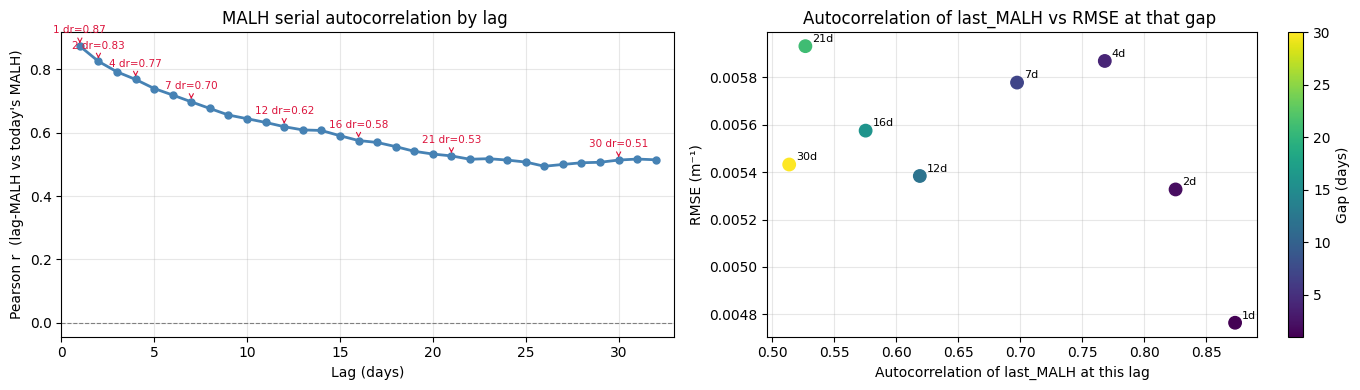

Autocorrelation at each gap day tested in sweep:
  lag= 1d  r=0.873
  lag= 2d  r=0.825
  lag= 4d  r=0.768
  lag= 7d  r=0.697
  lag=12d  r=0.619
  lag=16d  r=0.575
  lag=21d  r=0.527
  lag=30d  r=0.514


In [23]:
# ── §7b.3  MALH serial autocorrelation by lag ────────────────────────────────
# If MALH at lag-4 is a WORSE predictor of today's MALH than lag-12,
# it means the bloom cycle has a temporal structure (e.g. bloom events
# persist ≥12 days, so lag-12 still "sees" the same bloom, while
# lag-4 may straddle a bloom onset/collapse where MALH changes fast).

# Use only the full dataset (temporal sequences intact)
df_autocorr = sort_df_full[sort_df_full['source'] == 'full'].copy() if 'source' in sort_df_full.columns else sort_df_full.copy()
df_autocorr = df_autocorr.sort_values(['station', 'year', '_sort'] if '_sort' in df_autocorr.columns else ['station', 'year'])

max_lag = max(GAP_DAYS_LIST) + 2
lags, corrs, n_pairs = [], [], []

for lag in range(1, max_lag + 1):
    shifted = df_autocorr.groupby(['station', 'year'])['MALH'].shift(lag)
    valid   = df_autocorr['MALH'].notna() & shifted.notna()
    if valid.sum() < 10:
        continue
    r = np.corrcoef(df_autocorr.loc[valid, 'MALH'], shifted[valid])[0, 1]
    lags.append(lag)
    corrs.append(r)
    n_pairs.append(int(valid.sum()))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(lags, corrs, 'o-', color='steelblue', lw=2, ms=5)
for g in GAP_DAYS_LIST:
    if g in lags:
        idx = lags.index(g)
        ax.annotate(f'{g} dr={corrs[idx]:.2f}',
                    xy=(g, corrs[idx]), xytext=(g, corrs[idx] + 0.04),
                    fontsize=7.5, ha='center', color='crimson',
                    arrowprops=dict(arrowstyle='->', color='crimson', lw=0.8))
ax.axhline(0, color='grey', lw=0.8, ls='--')
ax.set_xlabel('Lag (days)'); ax.set_ylabel("Pearson r  (lag-MALH vs today's MALH)")
ax.set_title('MALH serial autocorrelation by lag ') ## (non-monotonic correlation ↔ non-monotonic RMSE)'
ax.grid(alpha=0.3)
ax.set_xlim(0, max_lag + 1)

ax2 = axes[1]
# Compare autocorr at gap days vs sweep RMSE
corr_at_gap = []
for g in gaps_r:
    if g in lags:
        corr_at_gap.append(corrs[lags.index(g)])
    else:
        corr_at_gap.append(np.nan)

rmses_r = [sweep_rich[g]['rmse'] for g in gaps_r]
sc = ax2.scatter(corr_at_gap, rmses_r, c=gaps_r, cmap='viridis', s=80, zorder=3)
for i, g in enumerate(gaps_r):
    if not np.isnan(corr_at_gap[i]):
        ax2.annotate(f'{g}d', (corr_at_gap[i], rmses_r[i]),
                     textcoords='offset points', xytext=(5, 3), fontsize=8)
plt.colorbar(sc, ax=ax2, label='Gap (days)')
ax2.set_xlabel("Autocorrelation of last_MALH at this lag")
ax2.set_ylabel('RMSE (m⁻¹)')
ax2.set_title('Autocorrelation of last_MALH vs RMSE at that gap ')  ### '(higher autocorr → more useful last_MALH → model should do better)'
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'diag_malh_autocorr.png', dpi=150, bbox_inches='tight')
plt.show()

print("Autocorrelation at each gap day tested in sweep:")
for g in gaps_r:
    if g in lags:
        r_val = corrs[lags.index(g)]
        print(f"  lag={g:2d}d  r={r_val:.3f}")


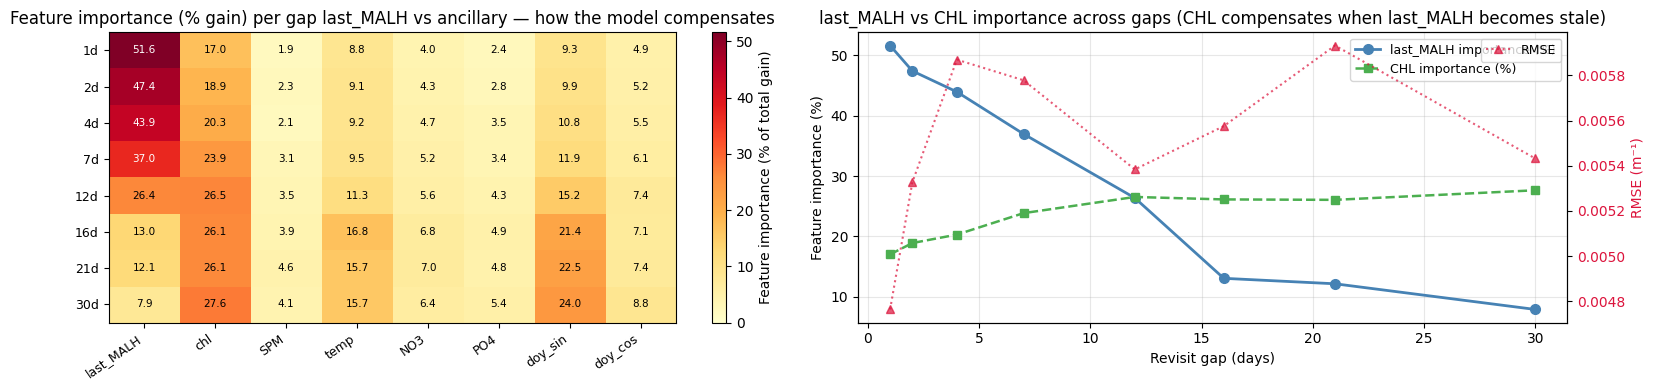


Key message:
  As gap increases, last_MALH importance decreases.
  The model compensates with CHL and seasonality (DOY).
  RMSE is non-monotonic because the CHL signal quality differs
  across the differently-composed test sets at each gap size.


In [24]:
# ── §7b.4  Feature compensation heatmap ──────────────────────────────────────
# Demonstrates that as last_MALH grows stale, the model compensates
# by increasing reliance on ancillary features (CHL, DOY, temp, etc.).
# The non-monotonic RMSE arises because some ancillary features are better
# proxies for the *specific* test rows surviving at certain gap sizes.

anc_labels = ANC_TRACK  # ['chl', 'SPM', 'temp', 'NO3', 'PO4', 'doy_sin', 'doy_cos']

# Build matrix: rows = gaps, cols = [last_MALH] + ANC_TRACK
feat_labels = ['last_MALH'] + anc_labels
imp_matrix  = np.zeros((len(gaps_r), len(feat_labels)))

for i, g in enumerate(gaps_r):
    imp_matrix[i, 0] = sweep_rich[g]['last_MALH_imp']
    for j, anc in enumerate(anc_labels):
        imp_matrix[i, j + 1] = sweep_rich[g]['anc_imp'].get(anc, 0.0)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# ── Heatmap ───────────────────────────────────────────────────────────────
ax = axes[0]
im = ax.imshow(imp_matrix, aspect='auto', cmap='YlOrRd', vmin=0)
ax.set_xticks(range(len(feat_labels)))
ax.set_xticklabels(feat_labels, rotation=35, ha='right', fontsize=9)
ax.set_yticks(range(len(gaps_r)))
ax.set_yticklabels([f'{g}d' for g in gaps_r], fontsize=9)
ax.set_title('Feature importance (% gain) per gap '
             'last_MALH vs ancillary — how the model compensates')
plt.colorbar(im, ax=ax, label='Feature importance (% of total gain)')
# Annotate cells
for i in range(len(gaps_r)):
    for j in range(len(feat_labels)):
        ax.text(j, i, f'{imp_matrix[i,j]:.1f}', ha='center', va='center',
                fontsize=7.5,
                color='white' if imp_matrix[i,j] > imp_matrix.max()*0.6 else 'black')

# ── Line plot: last_MALH imp vs RMSE ─────────────────────────────────────
ax2 = axes[1]
lm_imps  = [sweep_rich[g]['last_MALH_imp'] for g in gaps_r]
rmses_r2 = [sweep_rich[g]['rmse']          for g in gaps_r]
chl_imps = [sweep_rich[g]['anc_imp'].get('chl', 0) for g in gaps_r]

ax2.plot(gaps_r, lm_imps,  'o-', color='steelblue',   lw=2, ms=7, label='last_MALH importance (%)')
ax2.plot(gaps_r, chl_imps, 's--', color='#4caf50',    lw=1.8, ms=6, label='CHL importance (%)')
ax2.set_xlabel('Revisit gap (days)'); ax2.set_ylabel('Feature importance (%)')
ax2.set_title('last_MALH vs CHL importance across gaps '
              '(CHL compensates when last_MALH becomes stale)')
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

ax3 = ax2.twinx()
ax3.plot(gaps_r, rmses_r2, '^:', color='crimson', lw=1.5, ms=6, label='RMSE', alpha=0.7)
ax3.set_ylabel('RMSE (m⁻¹)', color='crimson')
ax3.tick_params(axis='y', labelcolor='crimson')
ax3.legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig(FIG_DIR / 'diag_feature_compensation.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey message:")
print("  As gap increases, last_MALH importance decreases.")
print("  The model compensates with CHL and seasonality (DOY).")
print("  RMSE is non-monotonic because the CHL signal quality differs")
print("  across the differently-composed test sets at each gap size.")


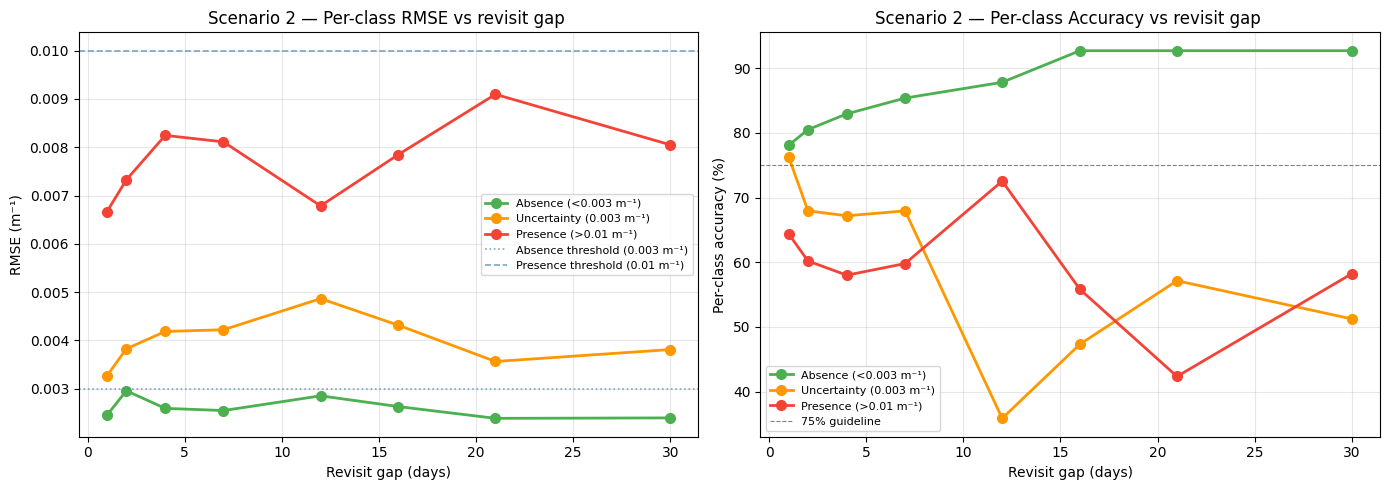

Per-class RMSE per gap (m⁻¹)
  Gap | n_test |  Absence RMSE |  Uncert RMSE |  Presence RMSE | Pres fraction
------------------------------------------------------------------------------
   1d |    276 |       0.00245 |      0.00327 |        0.00667 |         37.7%
   2d |    275 |       0.00296 |      0.00382 |        0.00733 |         37.5%
   4d |    272 |       0.00259 |      0.00419 |        0.00825 |         36.8%
   7d |    269 |       0.00255 |      0.00422 |        0.00811 |         36.1%
  12d |    263 |       0.00285 |      0.00486 |        0.00679 |         34.6%
  16d |    258 |       0.00263 |      0.00431 |        0.00785 |         33.3%
  21d |    252 |       0.00238 |      0.00356 |        0.00910 |         33.7%
  30d |    241 |       0.00239 |      0.00381 |        0.00805 |         32.8%


In [25]:
# ── §7b.5  Per-class RMSE and accuracy vs revisit gap ────────────────────────
# Shows which bloom class drives the non-monotonic behavior.
# The Presence class (active bloom) typically has the highest RMSE and
# most variability — its changing fraction in the test set (§7b.2) is
# the primary driver of the aggregate RMSE non-monotonicity.

class_colors = {'Absence': '#4caf50', 'Uncertainty': '#ff9800', 'Presence': '#f44336'}
class_labels = ['Absence', 'Uncertainty', 'Presence']
thresholds   = [T_ABSENCE, T_PRESENCE]
thresh_labels = [f'Absence threshold ({T_ABSENCE} m⁻¹)',
                 f'Presence threshold ({T_PRESENCE} m⁻¹)']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax_idx, (metric_key, ylabel, title_sfx, thresh_lines) in enumerate([
    ('rmse', 'RMSE (m⁻¹)', 'RMSE vs revisit gap', True),
    ('acc',  'Per-class accuracy (%)', 'Accuracy vs revisit gap', False),
]):
    ax = axes[ax_idx]
    for cls in class_labels:
        vals = []
        for g in gaps_r:
            pc = sweep_rich[g]['per_class'][cls]
            if metric_key == 'rmse':
                vals.append(pc['rmse'] if pc['n'] > 0 else np.nan)
            else:
                vals.append(pc['acc'] * 100 if pc['n'] > 0 else np.nan)
        ax.plot(gaps_r, vals, 'o-', color=class_colors[cls], lw=2, ms=7,
                label=f"{cls} ({'<' if cls=='Absence' else '>' if cls=='Presence' else ''}"
                      f"{T_ABSENCE if cls in ['Absence','Uncertainty'] else T_PRESENCE} m⁻¹)")

    if thresh_lines:
        for t, ls, lbl in zip(thresholds, [':', '--'], thresh_labels):
            ax.axhline(t, color='steelblue', ls=ls, lw=1.2, alpha=0.7, label=lbl)
    else:
        ax.axhline(75, color='grey', ls='--', lw=0.8, label='75% guideline')

    ax.set_xlabel('Revisit gap (days)'); ax.set_ylabel(ylabel)
    ax.set_title(f'Scenario 2 — Per-class {title_sfx} ')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'diag_perclass_rmse_accuracy_gap.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Diagnosis table ───────────────────────────────────────────────────────────
print("Per-class RMSE per gap (m⁻¹)")
header = f"{'Gap':>5} | {'n_test':>6} | {'Absence RMSE':>13} | {'Uncert RMSE':>12} | {'Presence RMSE':>14} | {'Pres fraction':>13}"
print(header)
print("-" * len(header))
for g in gaps_r:
    r = sweep_rich[g]
    pc = r['per_class']
    print(f" {g:3d}d | {r['n_test']:6d} | "
          f"{pc['Absence']['rmse']:13.5f} | "
          f"{pc['Uncertainty']['rmse']:12.5f} | "
          f"{pc['Presence']['rmse']:14.5f} | "
          f"{r['cls_frac']['Presence']:13.1%}")


In [26]:
# ── §7b.6  Gap classification table ─────────────────────────────────────
baseline_rmse = sweep_rich[1]['rmse']
T_excellent   = baseline_rmse * 1.15
T_acceptable  = baseline_rmse * 1.30

regime_map = {
    1:  ('Fresh last_MALH',      ' Stable'),
    2:  ('Transitioning',        ' Transition'),
    4:  ('Transition zone 1',    ' Unstable'),
    7:  ('Transition zone 1',    ' Unstable'),
    12: ('Dual-signal valley',   ' Stable'),
    16: ('Transition zone 2',    ' Transition'),
    21: ('Transition zone 2',    ' Unstable'),
    30: ('Phenology valley',     ' Stable'),
}

print(f"Baseline (1d) RMSE = {baseline_rmse:.4f} m⁻¹")
print(f"Excellent threshold : ≤ {T_excellent:.4f} m⁻¹ (+15%)")
print(f"Acceptable threshold: ≤ {T_acceptable:.4f} m⁻¹ (+30%)")
print()
print(f"{'Gap':>5} | {'RMSE':>8} | {'Δ baseline':>10} | {'Regime':>22} | Rating")
print("-" * 72)

for g in gaps_r:
    rmse  = sweep_rich[g]['rmse']
    delta = (rmse - baseline_rmse) / baseline_rmse * 100
    regime_label, regime_icon = regime_map.get(g, ('Unknown', '?'))

    if rmse <= T_excellent and '' in regime_icon:
        rating = ' Excellent'
    elif rmse <= T_acceptable and '' not in regime_icon:
        rating = ' Acceptable'
    else:
        rating = ' Degraded'

    print(f" {g:3d}d | {rmse:.4f}   | {delta:+.1f}%      | "
          f"{regime_label:>22} | {rating}")

Baseline (1d) RMSE = 0.0048 m⁻¹
Excellent threshold : ≤ 0.0055 m⁻¹ (+15%)
Acceptable threshold: ≤ 0.0062 m⁻¹ (+30%)

  Gap |     RMSE | Δ baseline |                 Regime | Rating
------------------------------------------------------------------------
   1d | 0.0048   | +0.0%      |        Fresh last_MALH |  Excellent
   2d | 0.0053   | +11.8%      |          Transitioning |  Excellent
   4d | 0.0059   | +23.2%      |      Transition zone 1 |  Degraded
   7d | 0.0058   | +21.3%      |      Transition zone 1 |  Degraded
  12d | 0.0054   | +13.0%      |     Dual-signal valley |  Excellent
  16d | 0.0056   | +17.0%      |      Transition zone 2 |  Degraded
  21d | 0.0059   | +24.5%      |      Transition zone 2 |  Degraded
  30d | 0.0054   | +14.0%      |       Phenology valley |  Excellent


## §8. Side-by-Side Comparison: Scenario 1 vs Scenario 2

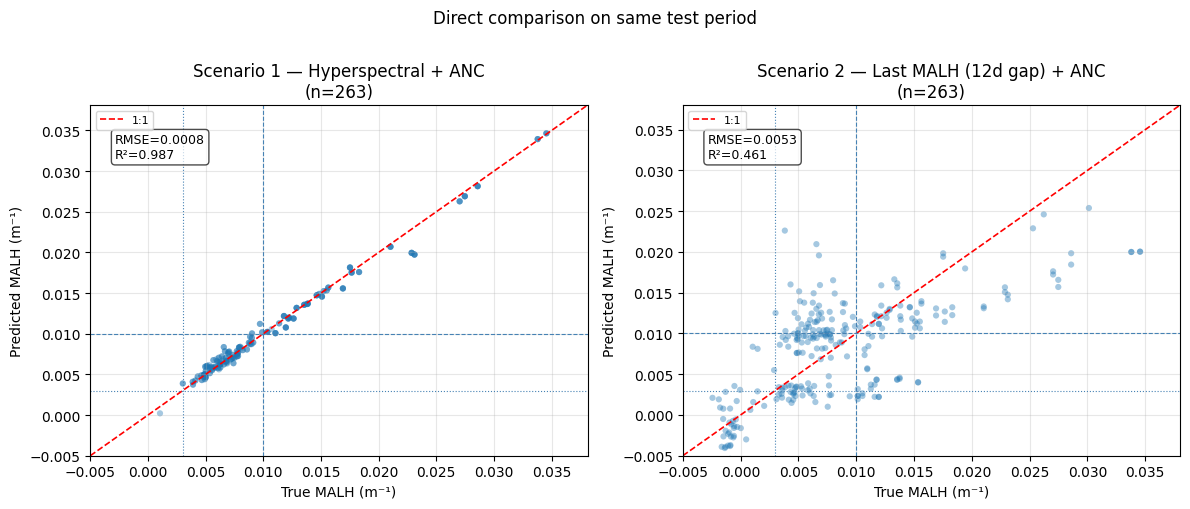

──────────────────────────────────────────
  Scenario 1 — Hyperspectral + ANC
  RMSE : 0.00077 m⁻¹
  R²   : 0.9875
  Bias : -0.00010 m⁻¹
──────────────────────────────────────────
──────────────────────────────────────────
  Scenario 2 — Last MALH (12d gap) + ANC
  RMSE : 0.00528 m⁻¹
  R²   : 0.4611
  Bias : -0.00038 m⁻¹
──────────────────────────────────────────


In [27]:
n = min(len(y_test), len(y_te_g))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
scatter_malh(y_test[:n], y_pred_hyp[:n],
             title=f'Scenario 1 — Hyperspectral + ANC\n(n={n})', ax=axes[0])
scatter_malh(y_te_g[:n], y_pred_gap[:n],
             title=f'Scenario 2 — Last MALH ({GAP_EXAMPLE}d gap) + ANC\n(n={n})', ax=axes[1])
plt.suptitle('Direct comparison on same test period', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'lgbm_comparison_4_1_vs_4_2.png', dpi=150, bbox_inches='tight')
plt.show()

for name, yt, yp in [('Scenario 1 — Hyperspectral + ANC', y_test[:n], y_pred_hyp[:n]),
                      (f'Scenario 2 — Last MALH ({GAP_EXAMPLE}d gap) + ANC', y_te_g[:n], y_pred_gap[:n])]:
    evaluate(yt, yp, title=name)

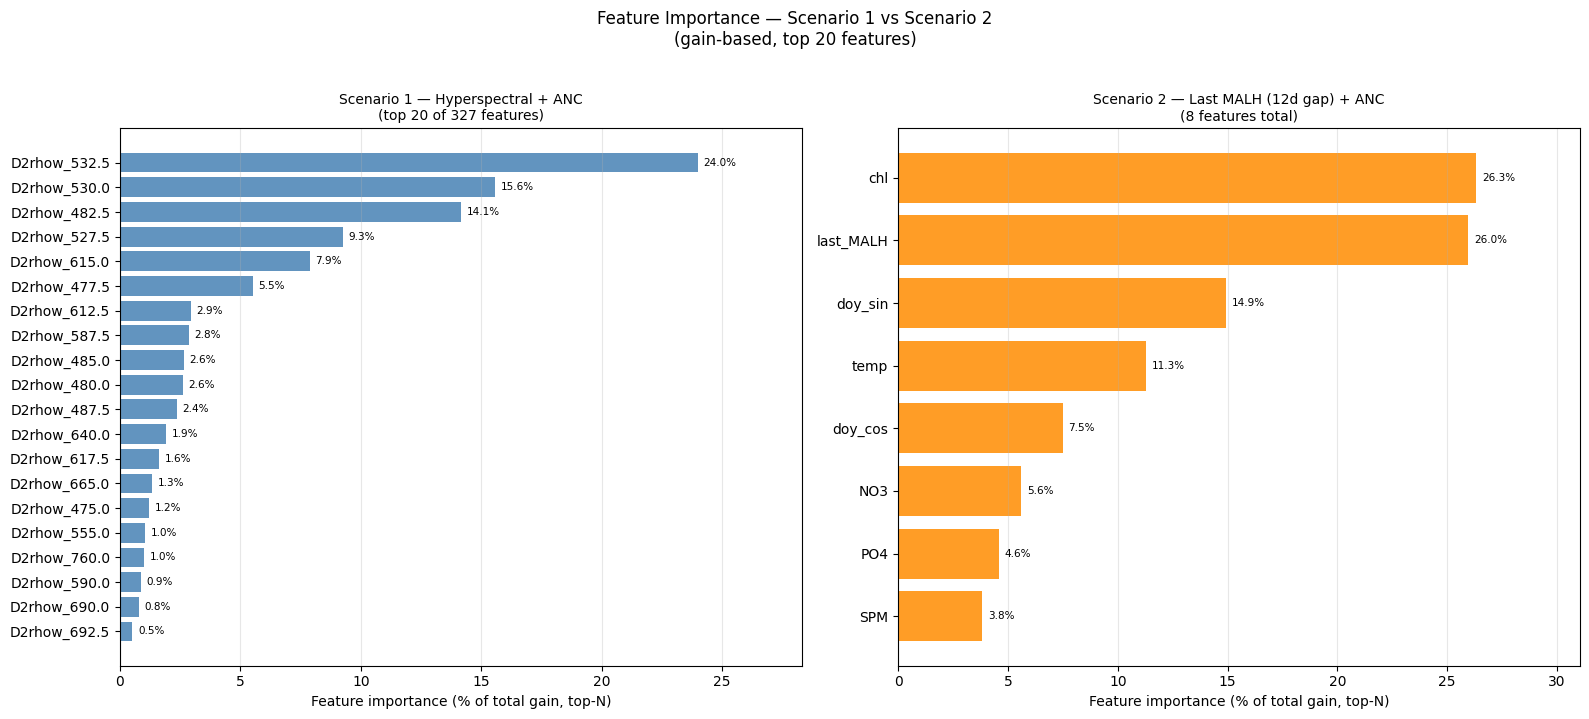


Top 10 — Scenario 1 — Hyperspectral + ANC
     feature  importance (%)
D2rhow_532.5           23.98
D2rhow_530.0           15.56
D2rhow_482.5           14.15
D2rhow_527.5            9.26
D2rhow_615.0            7.87
D2rhow_477.5            5.50
D2rhow_612.5            2.95
D2rhow_587.5            2.85
D2rhow_485.0            2.64
D2rhow_480.0            2.60

Top 10 — Scenario 2 — Last MALH 12d + ANC
  feature  importance (%)
      chl           26.31
last_MALH           25.95
  doy_sin           14.95
     temp           11.27
  doy_cos            7.48
      NO3            5.61
      PO4            4.59
      SPM            3.83


In [28]:
# ── §8.1  Feature Importance — Scenario 1 vs Scenario 2 ─────────────────────
TOP_N = 20

# ── Extract gain importance ───────────────────────────────────────────────
imp_41 = model_hyp.booster_.feature_importance(importance_type='gain')
fi_41  = (pd.DataFrame({'feature': FEATURE_COLS, 'importance': imp_41})
            .sort_values('importance', ascending=False)
            .head(TOP_N)
            .reset_index(drop=True))

imp_42 = model_gap.booster_.feature_importance(importance_type='gain')
fi_42  = (pd.DataFrame({'feature': GAP_FEATS, 'importance': imp_42})
            .sort_values('importance', ascending=False)
            .head(TOP_N)
            .reset_index(drop=True))

# Normalise to % of total gain shown (makes panels visually comparable)
fi_41['pct'] = fi_41['importance'] / fi_41['importance'].sum() * 100
fi_42['pct'] = fi_42['importance'] / fi_42['importance'].sum() * 100

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

panels = [
    (axes[0], fi_41, FEATURE_COLS,
     f'Scenario 1 — Hyperspectral + ANC\n(top {TOP_N} of {len(FEATURE_COLS)} features)',
     'steelblue'),
    (axes[1], fi_42, GAP_FEATS,
     f'Scenario 2 — Last MALH ({GAP_EXAMPLE}d gap) + ANC\n({len(GAP_FEATS)} features total)',
     'darkorange'),
]

for ax, fi, all_feats, title, color in panels:
    bars = ax.barh(fi['feature'][::-1], fi['pct'][::-1], color=color, alpha=0.85)
    ax.set_xlabel('Feature importance (% of total gain, top-N)')
    ax.set_title(title, fontsize=10)
    ax.grid(alpha=0.3, axis='x')
    # Annotate bars
    x_max = fi['pct'].max()
    for i, val in enumerate(fi['pct'][::-1]):
        ax.text(val + x_max * 0.01, i, f'{val:.1f}%', va='center', fontsize=7.5)
    ax.set_xlim(right=x_max * 1.18)

plt.suptitle('Feature Importance — Scenario 1 vs Scenario 2\n(gain-based, top 20 features)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'lgbm_feature_importance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Print summary ─────────────────────────────────────────────────────────
for label, fi in [('Scenario 1 — Hyperspectral + ANC', fi_41),
                  (f'Scenario 2 — Last MALH {GAP_EXAMPLE}d + ANC', fi_42)]:
    print(f"\nTop 10 — {label}")
    print(fi[['feature', 'pct']].rename(columns={'pct': 'importance (%)'})
            .head(10).to_string(index=False, float_format='{:.2f}'.format))

## §9. Error analysis by class and by station

In [29]:
# ── §9. Error analysis by class and by station ───────────────────────────────
# Rebuild test dataframe with predictions attached
test_analysis = test_df[['station','year','MALH'] + 
                         [c for c in test_df.columns if c in ['source']]].copy()
test_analysis['y_pred']      = y_pred_hyp
test_analysis['error']       = y_pred_hyp - test_df['MALH'].values
test_analysis['abs_error']   = np.abs(test_analysis['error'])
test_analysis['true_class']  = malh_to_class(test_df['MALH'].values)
test_analysis['pred_class']  = malh_to_class(y_pred_hyp)
test_analysis['correct']     = test_analysis['true_class'] == test_analysis['pred_class']

CLASS_SHORT = {0: 'Absence', 1: 'Uncertainty', 2: 'Presence'}

# ── Per-class RMSE and bias ───────────────────────────────────────────────────
print("=== Case 4.1 — Metrics per true MALH class ===")
for cls in [0, 1, 2]:
    sub = test_analysis[test_analysis['true_class'] == cls]
    if len(sub) == 0:
        continue
    rmse = np.sqrt(mean_squared_error(sub['MALH'], sub['y_pred']))
    bias = sub['error'].mean()
    acc  = sub['correct'].mean()
    print(f"  {CLASS_SHORT[cls]:12s} (n={len(sub):3d}) | "
          f"RMSE={rmse:.5f}  Bias={bias:+.5f}  ClassAcc={acc:.1%}")

print()

# ── Per-station RMSE and classification accuracy ──────────────────────────────
print("=== Case 4.1 — Metrics per station ===")
for sta in sorted(test_analysis['station'].unique()):
    sub = test_analysis[test_analysis['station'] == sta]
    rmse = np.sqrt(mean_squared_error(sub['MALH'], sub['y_pred']))
    r2   = r2_score(sub['MALH'], sub['y_pred'])
    acc  = sub['correct'].mean()
    print(f"  {sta:8s} (n={len(sub):3d}) | "
          f"RMSE={rmse:.5f}  R²={r2:.3f}  ClassAcc={acc:.1%}")
    # Per-class breakdown within station
    for cls in [0, 1, 2]:
        sub2 = sub[sub['true_class'] == cls]
        if len(sub2) == 0: continue
        print(f"    └ {CLASS_SHORT[cls]:12s} n={len(sub2):3d}  "
              f"acc={sub2['correct'].mean():.1%}")

=== Case 4.1 — Metrics per true MALH class ===
  Absence      (n= 41) | RMSE=0.00053  Bias=-0.00032  ClassAcc=100.0%
  Uncertainty  (n=246) | RMSE=0.00057  Bias=+0.00016  ClassAcc=95.1%
  Presence     (n=152) | RMSE=0.00118  Bias=-0.00063  ClassAcc=92.1%

=== Case 4.1 — Metrics per station ===
  CPOWER   (n= 11) | RMSE=0.00061  R²=0.906  ClassAcc=100.0%
    └ Uncertainty  n= 10  acc=100.0%
    └ Presence     n=  1  acc=100.0%
  RT1      (n=428) | RMSE=0.00084  R²=0.984  ClassAcc=94.4%
    └ Absence      n= 41  acc=100.0%
    └ Uncertainty  n=236  acc=94.9%
    └ Presence     n=151  acc=92.1%


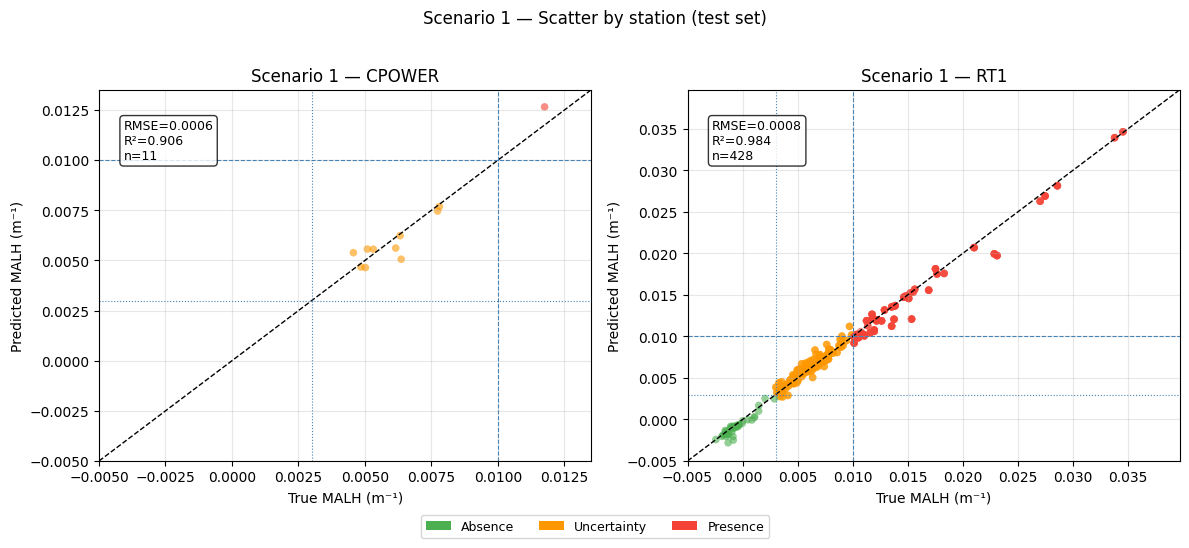

In [30]:
# ── Scatter plots per station ─────────────────────────────────────────────────
stations = sorted(test_analysis['station'].unique())
fig, axes = plt.subplots(1, len(stations), figsize=(6*len(stations), 5))
if len(stations) == 1:
    axes = [axes]

for ax, sta in zip(axes, stations):
    sub = test_analysis[test_analysis['station'] == sta]
    colors = ['#4caf50' if c==0 else '#ff9800' if c==1 else '#f44336'
              for c in sub['true_class']]
    ax.scatter(sub['MALH'], sub['y_pred'], c=colors, alpha=0.6, s=30, edgecolors='none')
    lim = (min(-0.005, sub['MALH'].min()*1.1), sub['MALH'].max()*1.15)
    ax.plot(lim, lim, 'k--', lw=1, label='1:1')
    for t, ls in [(T_ABSENCE, ':'), (T_PRESENCE, '--')]:
        ax.axvline(t, color='steelblue', lw=0.8, ls=ls)
        ax.axhline(t, color='steelblue', lw=0.8, ls=ls)
    rmse = np.sqrt(mean_squared_error(sub['MALH'], sub['y_pred']))
    r2   = r2_score(sub['MALH'], sub['y_pred'])
    ax.text(0.05, 0.92, f'RMSE={rmse:.4f}\nR²={r2:.3f}\nn={len(sub)}',
            transform=ax.transAxes, va='top', fontsize=9,
            bbox=dict(boxstyle='round', fc='white', alpha=0.8))
    ax.set_xlabel('True MALH (m⁻¹)'); ax.set_ylabel('Predicted MALH (m⁻¹)')
    ax.set_title(f'Scenario 1 — {sta}')
    ax.set_xlim(lim); ax.set_ylim(lim); ax.grid(alpha=0.3)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(fc='#4caf50', label='Absence'),
                   Patch(fc='#ff9800', label='Uncertainty'),
                   Patch(fc='#f44336', label='Presence')]
fig.legend(handles=legend_elements, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.05), fontsize=9)
plt.suptitle('Scenario 1 — Scatter by station (test set)', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'lgbm_scatter_by_station.png', dpi=150, bbox_inches='tight')
plt.show()